In [20]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

In [21]:
churn_dataset=df= pd.read_csv("C:/Users/PMLS/OneDrive/Desktop/ehunar_session/customer churn prediction model/customer_churn_dataset-testing-master.csv")

In [22]:
churn_dataset.head()

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,1,22,Female,25,14,4,27,Basic,Monthly,598,9,1
1,2,41,Female,28,28,7,13,Standard,Monthly,584,20,0
2,3,47,Male,27,10,2,29,Premium,Annual,757,21,0
3,4,35,Male,9,12,5,17,Premium,Quarterly,232,18,0
4,5,53,Female,58,24,9,2,Standard,Annual,533,18,0


In [23]:
churn_dataset.tail()

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
64369,64370,45,Female,33,12,6,21,Basic,Quarterly,947,14,1
64370,64371,37,Male,6,1,5,22,Standard,Annual,923,9,1
64371,64372,25,Male,39,14,8,30,Premium,Monthly,327,20,1
64372,64373,50,Female,18,19,7,22,Standard,Monthly,540,13,1
64373,64374,52,Female,45,15,9,25,Standard,Monthly,696,22,1


In [24]:
churn_dataset.describe()

,CustomerID,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction,Churn
count,64374.000000,64374.000000,64374.000000,64374.000000,64374.000000,64374.000000,64374.000000,64374.000000,64374.000000
mean,32187.500000,41.970982,31.994827,15.080234,5.400690,17.133952,541.023379,15.498850,0.473685
std,18583.317451,13.924911,17.098234,8.816470,3.114005,8.852211,260.874809,8.638436,0.499311
min,1.000000,18.000000,1.000000,1.000000,0.000000,0.000000,100.000000,1.000000,0.000000
25%,16094.250000,30.000000,18.000000,7.000000,3.000000,10.000000,313.000000,8.000000,0.000000
50%,32187.500000,42.000000,33.000000,15.000000,6.000000,19.000000,534.000000,15.000000,0.000000
75%,48280.750000,54.000000,47.000000,23.000000,8.000000,25.000000,768.000000,23.000000,1.000000
max,64374.000000,65.000000,60.000000,30.000000,10.000000,30.000000,1000.000000,30.000000,1.000000


In [ ]:

churn_dataset.shape

(64374, 12)

In [ ]:

churn_dataset.dtypes

CustomerID            int64
Age                   int64
Gender               object
Tenure                int64
Usage Frequency       int64
Support Calls         int64
Payment Delay         int64
Subscription Type    object
Contract Length      object
Total Spend           int64
Last Interaction      int64
Churn                 int64
dtype: object

In [ ]:

df.isnull().sum()


CustomerID           0
Age                  0
Gender               0
Tenure               0
Usage Frequency      0
Support Calls        0
Payment Delay        0
Subscription Type    0
Contract Length      0
Total Spend          0
Last Interaction     0
Churn                0
dtype: int64

In [ ]:

df['Churn'].value_counts()

Churn
0    33881
1    30493
Name: count, dtype: int64

In [ ]:

df['Churn'].value_counts(normalize=True) * 100

Churn
0    52.631497
1    47.368503
Name: proportion, dtype: float64

In [ ]:

print(df['Gender'].unique())
print(df['Subscription Type'].unique())
print(df['Contract Length'].unique())

['Female' 'Male']
['Basic' 'Standard' 'Premium']
['Monthly' 'Annual' 'Quarterly']


In [ ]:

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['Gender'] = le.fit_transform(df['Gender'])
df['Subscription Type'] = le.fit_transform(df['Subscription Type'])
df['Contract Length'] = le.fit_transform(df['Contract Length'])

# Check karo
print(df[['Gender','Subscription Type','Contract Length']].head())

   Gender  Subscription Type  Contract Length
0       0                  0                1
1       0                  2                1
2       1                  1                0
3       1                  1                2
4       0                  2                0


In [ ]:
# drop useless column
df.drop('CustomerID', axis=1, inplace=True)

# Check karo
df.head()

,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,22,0,25,14,4,27,0,1,598,9,1
1,41,0,28,28,7,13,2,1,584,20,0
2,47,1,27,10,2,29,1,0,757,21,0
3,35,1,9,12,5,17,1,2,232,18,0
4,53,0,58,24,9,2,2,0,533,18,0


In [ ]:


X = df.drop('Churn', axis=1)  
y = df['Churn']              

# Check karo
print("X shape:", X.shape)
print("y shape:", y.shape)


X shape: (64374, 10)
y shape: (64374,)


In [34]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

X_train: (51499, 10)
X_test : (12875, 10)


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)



In [ ]:

from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)
print("Model trained")

Model trained


In [ ]:

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("prediction done")
print("Total predictions:", len(y_pred))

prediction done
Total predictions: 12875


In [ ]:

from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# 1. Accuracy
Accuracy= model.score(X_test, y_test) * 100
print("Accuracy:",Accuracy)

# 2. AUC Score
roc_auc_score=roc_auc_score(y_test, y_prob)
print("AUC Score:", roc_auc_score)

# 3. Confusion Matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# 4. Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 99.94563106796116
AUC Score: 0.9999994069954112

Confusion Matrix:
[[6792    1]
 [   6 6076]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      6793
           1       1.00      1.00      1.00      6082

    accuracy                           1.00     12875
   macro avg       1.00      1.00      1.00     12875
weighted avg       1.00      1.00      1.00     12875



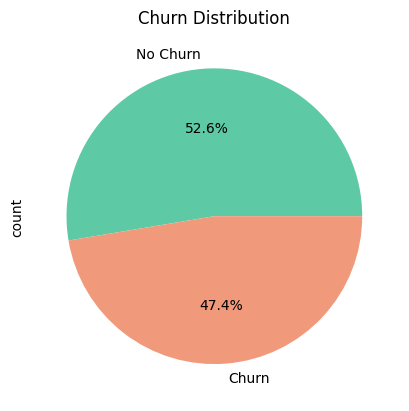

In [ ]:
import matplotlib.pyplot as plt

df['Churn'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    colors=['#5DCAA5', '#F0997B'],
    labels=['No Churn', 'Churn']
)
plt.title('Churn Distribution')
plt.show()

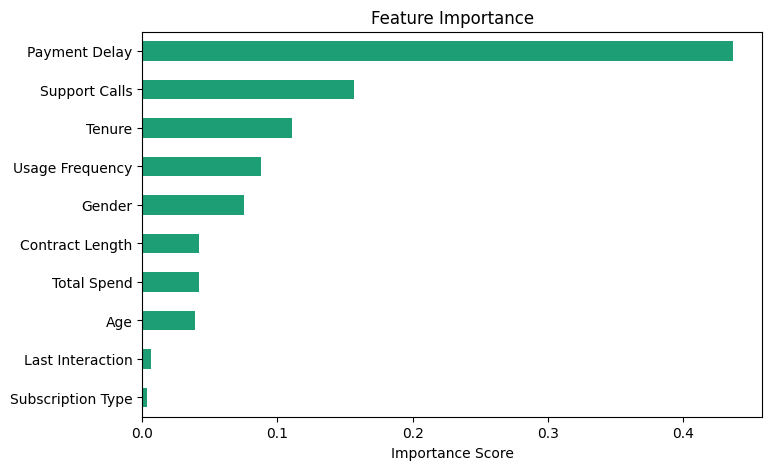

In [47]:
feat_imp = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

feat_imp.plot(
    kind='barh',
    color='#1D9E75',
    figsize=(8, 5)
)
plt.title('Feature Importance')
plt.xlabel('Importance Score')
plt.gca().invert_yaxis()
plt.show()

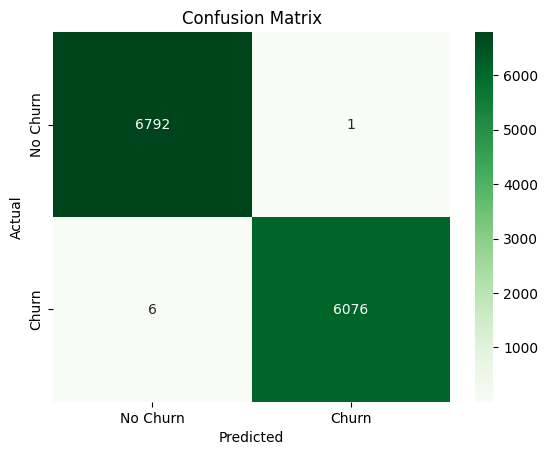

In [48]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=['No Churn', 'Churn'],
    yticklabels=['No Churn', 'Churn']
)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

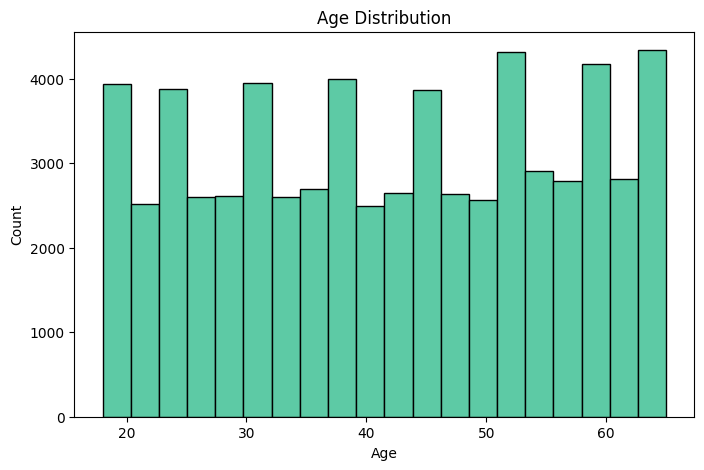

In [49]:
df['Age'].plot(
    kind='hist',
    bins=20,
    color='#5DCAA5',
    edgecolor='black',
    figsize=(8, 5)
)
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

AUC Score: 0.9999994069954112


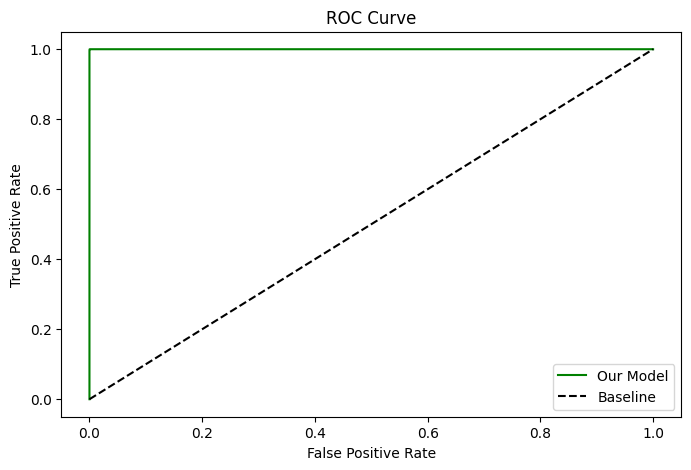

In [ ]:

from sklearn.metrics import roc_curve, roc_auc_score
fpr, tpr, _ = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)
print("AUC Score:", auc)

plt.figure(figsize=(8, 5))

plt.plot(fpr, tpr,
         color='green',
         label='Our Model')

plt.plot([0, 1], [0, 1],
         color='black',
         linestyle='--',
         label='Baseline')

plt.title('ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()